<a href="https://colab.research.google.com/github/Andrei-WongE/IDEAtlas_workshop/blob/origin/IDEAtlas_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌎 Taller en vivo IDEAtlas: Mapeo de asentamientos informales en América Latina y el Caribe

Bienvenido o bienvenida. En los proximos minutos vas a usar el mismo pipeline de IA que impulsa la plataforma IDEAtlas, desarrollada para ayudar a naciones,  gobiernos locales y comunidades al monitorear el [Objetivo de Desarrollo Sostenible 11.1.1](https://www.un.org/sustainabledevelopment/es/cities/) (la proporcion de la poblacion urbana que vive en asentamientos precarios, informales o con vivienda inadecuada).

Vas a hacer tres cosas:

1. **✏️ Dibujar** un area de interes en algun lugar del area metropolitana de Buenos Aires. Elegi un barrio que conozcas.
2. **🧠 Ejecutar** el modelo real de IDEAtlas sobre tu area.
3. **🗺️ Ver** el mapa que predice el modelo, superpuesto sobre la imagen satelital.

No hace falta experiencia previa con programacion. Cada paso a continuacion es un boton: solo tenes que ejecutar cada celda en orden ( ▶) y seguir las indicaciones.

> 💡 *Este notebook ejecuta los algoritmos reales de IDEAtlas (el mismo código y modelo detras de la plataforma), no es una simulacion.*


## 🧠 El algoritmo IDEAtlas

IDEAtlas usa una red neuronal convolucional liviana de multiples ramas (MB CNN) que analiza dos cosas juntas para cada pequeno sector de tu area seleccionada:

- **Imagenes satelitales Sentinel-2** (10 bandas espectrales, mucho mas alla de lo que ve el ojo humano: vegetacion, humedad, materiales)
- **Densidad de edificacion**, derivada de datos abiertos de huellas de construcciones

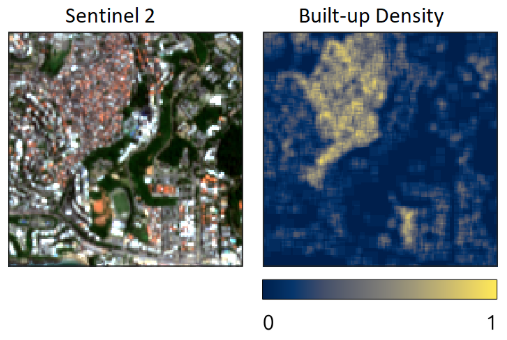

Todos **estos datos necesarios serán descargados de forma automática** para el área de interés definida.

El modelo estadístico que realizará el análisis fue entrenado con datos de referencia de varias ciudades, para reconocer las señales visuales y estructurales de las áreas urbanas deficitarias: patrones de construccion irregulares, densidad y materiales que difieren del desarrollo urbano formal y planificado.

Para cada sector, el modelo predice una de tres clases:

| Clase | Significado |
|---|---|
| ⬜ No urbanizado | Sin urbanizar |
| 🟦 Area urbana no deficitaria | Desarrollo urbano formal / regular |
| 🟥 Area urbana deficitaria (DUA) | Asentamiento informal / vivienda inadecuada |


---

A continuación instalaremos el software necesario, definiremos un área de intéres, y la analizaremos con este modelo.



## 🔧 Paso 1: Preparar el entorno del taller

**Ejecuta primero la Celda "Preparativos". Este paso es lento** (instala una distribucion completa de Python, más los paquetes de funciones requeridos para nuestro ejercicio). Tomará unos 6 minutos.

**Cuando termine, aceptamos el mensaje que nos solicita reiniciar la sesión** (como alternativa, también se logra con la opción de menú en la barra superior: Entorno de ejecucion > Reiniciar sesion).

Una vez que se reinicia la sesión, **no hace falta repetir este Paso 1** - vamos directo al **Paso 2**

In [1]:
#@title Instalación
# @markdown Ejecuta esto una sola vez para instalar en Colab todo el software que vamos a necesitar.
# @markdown Ten en cuenta que el proceso va a tomar algunos minutos.

print("Descargando el código de IDEAtlas...")
!git clone https://github.com/IDEAtlas/ai-dua-mapping.git

print("Instalando Python 3.10. Esto tarda un rato, ten paciencia...\n")

!wget -O mini.sh https://repo.anaconda.com/miniconda/Miniconda3-py310_22.11.1-1-Linux-x86_64.sh
!chmod +x mini.sh
!bash ./mini.sh -b -f -p /usr/local
!conda install -q -y jupyter
!conda install -q -y google-colab -c conda-forge
!python -m ipykernel install --name "py310" --user

print("Instalando paquetes requeridos...")
!apt-get install -y libgdal-dev
import os
os.environ['CPLUS_INCLUDE_PATH'] = '/usr/include/gdal'
os.environ['C_INCLUDE_PATH'] = '/usr/include/gdal'
!pip install --force-reinstall GDAL==$(gdal-config --version)
!pip install tensorflow==2.13.0 proj \
 fiona==1.9.6 geopandas xarray dask \
 pandas matplotlib tqdm s2sphere rioxarray rasterstats scikit-learn \
 pystac-client planetary-computer stackstac \
 segmentation-models odc-geo odc-stac



print("\nListo. Ahora reiniciar la sesión, y despues ejecutar el resto de las celdas.")


Descargando el código de IDEAtlas...
Cloning into 'ai-dua-mapping'...
remote: Enumerating objects: 1026, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 1026 (delta 14), reused 6 (delta 6), pack-reused 1002 (from 2)
Receiving objects: 100% (1026/1026), 3.32 MiB | 7.99 MiB/s, done.
Resolving deltas: 100% (522/522), done.
Instalando Python 3.10. Esto tarda un rato, ten paciencia...

--2026-07-23 20:36:36--  https://repo.anaconda.com/miniconda/Miniconda3-py310_22.11.1-1-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72402405 (69M) [application/x-sh]
Saving to: ‘mini.sh’

mini.sh             100%[===================>]  69.05M   383MB/s    in 0.2s    

2026-07-23 20:36:37 (383 MB/s) - ‘mini.sh’ saved [72402405/


Listo. Ahora reiniciar la sesión, y despues ejecutar el resto de las celdas.


## 🗺️ Paso 2: Definir el área de interés

Elegi una ciudad en el menu desplegable. El mapa se va a centrar automaticamente sobre ella (el recuadro amarillo punteado es solo una guia aproximada del area metropolitana, no un limite oficial).

**Usa la herramienta de poligono** (esquina superior izquierda del mapa) para dibujar alrededor de un barrio que conozcas. Manten un tamano moderado, unos pocos kilometros cuadrados, para que la IA pueda procesarlo rapido durante nuestro taller. Luego haz clic en **Confirmar Area**.

In [1]:
#@title Dibuja y confirma área de interés { display-mode: "form" }
#@markdown Elige una ciudad, dibuja un poligono en el mapa usando la herramienta de su esquina superior izquierda, y luego haz clic en Confirmar Area.

import os
os.chdir("/content/ai-dua-mapping")

import json
import ipywidgets as widgets
from ipyleaflet import Map, basemaps, DrawControl, Rectangle
from IPython.display import display, clear_output
from shapely.geometry import shape
import geopandas as gpd

REPO_DIR = "/content/ai-dua-mapping"

# Ciudades piloto de IDEAtlas disponibles para el taller.
# city/country usan el formato que espera main.py (ver README del repo):
# palabras compuestas separadas por guion.
CITIES = {
    "Ciudad de Mexico (Mexico)": {"city": "mexico-city", "country": "mexico", "center": (19.4326, -99.1332), "bounds": [(19.65, -99.35), (19.20, -98.90)]},
    "Medellin (Colombia)": {"city": "medellin", "country": "colombia", "center": (6.2442, -75.5812), "bounds": [(6.38, -75.72), (6.10, -75.44)]},
    "Salvador (Brasil)": {"city": "salvador", "country": "brazil", "center": (-12.9777, -38.5016), "bounds": [(-12.80, -38.68), (-13.15, -38.32)]},
    "Buenos Aires (Argentina)": {"city": "buenos-aires", "country": "argentina", "center": (-34.62, -58.50), "bounds": [(-34.35, -58.90), (-34.90, -58.10)]},
    "Rio de Janeiro (Brasil)": {"city": "rio-de-janeiro", "country": "brazil", "center": (-22.9068, -43.1729), "bounds": [(-22.65, -43.45), (-23.15, -43.10)]},
    "Guatemala (Guatemala)": {"city": "guatemala-city", "country": "guatemala", "center": (14.6349, -90.5069), "bounds": [(14.75, -90.65), (14.52, -90.40)]},
    "Pereira (Colombia)": {"city": "pereira", "country": "colombia", "center": (4.8087, -75.6906), "bounds": [(4.92, -75.80), (4.70, -75.58)]},
    "Tegucigalpa (Honduras)": {"city": "tegucigalpa", "country": "honduras", "center": (14.0723, -87.1921), "bounds": [(14.20, -87.32), (13.95, -87.07)]},
    "San Jose (Costa Rica)": {"city": "san-jose", "country": "costa-rica", "center": (9.9281, -84.0907), "bounds": [(10.05, -84.22), (9.82, -83.98)]},
}

city_dropdown = widgets.Dropdown(options=list(CITIES.keys()), value="Buenos Aires (Argentina)", description="Ciudad:")

initial = CITIES[city_dropdown.value]
m = Map(center=initial["center"], zoom=10, basemap=basemaps.Esri.WorldImagery, scroll_wheel_zoom=True)
guide_rect = Rectangle(bounds=initial["bounds"], color="#FFD400", fill=False, weight=2, dash_array="6,6")
m.add_layer(guide_rect)

draw_control = DrawControl(
    polygon={"shapeOptions": {"color": "#00C2A8", "fillOpacity": 0.1, "weight": 4}},
    rectangle={"shapeOptions": {"color": "#00C2A8", "fillOpacity": 0.1, "weight": 4}},
    circle={}, circlemarker={}, polyline={}, marker={}
)
m.add_control(draw_control)

status_out = widgets.Output()
confirm_btn = widgets.Button(description="Confirmar Area", button_style="success", icon="check")
aoi_state = {"geometry": None}

# Variables globales que usa el Paso 4
city = initial["city"]
country = initial["country"]

def on_city_change(change):
    global city, country, guide_rect
    if change["name"] != "value":
        return
    info = CITIES[change["new"]]
    city = info["city"]
    country = info["country"]
    m.center = info["center"]
    m.zoom = 10
    m.remove_layer(guide_rect)
    guide_rect = Rectangle(bounds=info["bounds"], color="#FFD400", fill=False, weight=2, dash_array="6,6")
    m.add_layer(guide_rect)
    draw_control.clear()
    aoi_state["geometry"] = None
    with status_out:
        clear_output()
        print(f"Ciudad seleccionada: {change['new']}. Dibuja tu area en el mapa.")

city_dropdown.observe(on_city_change, names="value")

def on_draw(target, action, geo_json):
    aoi_state["geometry"] = geo_json["geometry"]

draw_control.on_draw(on_draw)

def on_confirm_clicked(b):
    with status_out:
        clear_output()
        if aoi_state["geometry"] is None:
            print("Primero dibuja un poligono en el mapa, luego haz clic en Confirmar Area.")
            return

        geom = shape(aoi_state["geometry"])
        gdf = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
        area_km2 = gdf.to_crs(gdf.estimate_utm_crs()).area.iloc[0] / 1e6

        if area_km2 > 40:
            print(f"Tu area es de aproximadamente {area_km2:,.1f} km2, es bastante grande y puede tardar en procesarse.")
            print("Considera dibujar un area mas chica, del tamano de un barrio, para una demo mas rapida.")
        else:
            print(f"Area seleccionada en {city_dropdown.value}: {area_km2:,.2f} km2")

        # city_normalized debe coincidir EXACTO con normalize_city_name() de main.py:
        # minusculas, y tanto espacios como guiones pasan a guion bajo.
        city_normalized = f"{city}_{country}".lower().replace(" ", "_").replace("-", "_")
        out_path = os.path.join(REPO_DIR, "data/raw/aoi", f"{city_normalized}_aoi.geojson")
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        gdf.to_file(out_path, driver="GeoJSON")
        print(f"Area guardada para {city} / {country}. Ya podes pasar al Paso 4 para ejecutar la prediccion.")

confirm_btn.on_click(on_confirm_clicked)
display(city_dropdown, m, confirm_btn, status_out)


Dropdown(description='Ciudad:', index=3, options=('Ciudad de Mexico (Mexico)', 'Medellin (Colombia)', 'Salvado…

Map(center=[-34.62, -58.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

Button(button_style='success', description='Confirmar Area', icon='check', style=ButtonStyle())

Output()

## 🔍 Paso 3: Elegir un año y realizar la predicción

Define el año (por ejemplo, "2025"), y luego ejecuta el script de predicción. IDEAtlas va a buscar datos satelitales y de edificaciones para tu area y va a correr el algoritmo de clasificacion (`main.py --task classify`).

Las variables {city} y {country} indican el área donde aplicar el algoritmod e predicción, algo útil cuando tenemos varias ciudades bajo análisis. Para este ejercicio, ya han sido cargadas con la ciudad y país correspondientes al realizar el paso de definir el área de interés.

In [ ]:
!python main.py --task classify --city {city} --country {country} --year 2025


[2026-07-18 15:43:35] [INFO] CLASSIFICATION WORKFLOW START
[2026-07-18 15:43:35] [INFO] City: Medellin, Country: Colombia, Year: 2025, Model: MBCNN
[2026-07-18 15:43:35] [INFO] [1/2] Preparing Data...
Computing built-up density: 100% 6/6 [01:27<00:00, 14.56s/step]
[2026-07-18 15:45:06] [INFO] Data preparation complete
[2026-07-18 15:45:08] [INFO] [2/2] Running Classification...
[2026-07-18 15:45:09] [INFO] Loaded weights from: ./checkpoint/global.s2.bd.mbcnn.weights.h5
Progress: 100% 6/6 [00:01<00:00,  3.84it/s]

Classification map saved to: ./output/medellin_colombia.s2.bd.mbcnn.2025.tif


## 🎨 Paso 4: Evaluar los resultados

Aqui esta la prediccion de la IA para tu area, superpuesta sobre la imagen satelital. Usa el control de capas (esquina superior derecha del mapa) para activar y desactivar cada clase.

In [ ]:
#@title Mostrar los resultados en el mapa { display-mode: "form" }
#@markdown Ejecuta esto despues de que termine el Paso 3.

import os, json, sys
import geopandas as gpd
from ipyleaflet import Map, basemaps, GeoJSON, LayersControl
from IPython.display import display, HTML

# Ensure we are in the right directory and use the installed libraries
REPO_DIR = "/content/ai-dua-mapping"
if os.path.exists(REPO_DIR):
    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)
    # Force local site-packages if kernel didn't switch
    sys.path.append("/usr/local/lib/python3.10/site-packages")

try:
    from utils.sdg_stats import polygonize_builtup_classes
except ImportError:
    print("Error: No se encuentran las librerias. Asegurate de que el Paso 1 (Preparativos) termino sin errores.")
    raise

year = globals().get("LAST_RUN_YEAR", "2025")
city_normalized = f"{city}_{country}".lower().replace(" ", "_").replace("-", "_")
raster_path = os.path.join(REPO_DIR, "output", f"{city_normalized}.s2.bd.mbcnn.{year}.tif")
aoi_path = os.path.join(REPO_DIR, "data/raw/aoi", f"{city_normalized}_aoi.geojson")

CLASS_INFO = {
    1: {"label": "No urbanizado", "color": "#B0B0B0"},
    2: {"label": "Area urbana (no deficitaria)", "color": "#2E7DD7"},
    3: {"label": "Area urbana deficitaria (DUA)", "color": "#E4572E"},
}

if not os.path.exists(raster_path):
    print(f"No se encontro el archivo: {raster_path}. Corre el Paso 4 primero.")
else:
    gdf = polygonize_builtup_classes(raster_path, class_values=[1, 2, 3]).to_crs("EPSG:4326")
    aoi = gpd.read_file(aoi_path)
    center = aoi.geometry.iloc[0].centroid

    m = Map(center=(center.y, center.x), zoom=15, basemap=basemaps.Esri.WorldImagery)

    for class_val, info in CLASS_INFO.items():
        subset = gdf[gdf["class"] == class_val]
        if subset.empty:
            continue
        layer = GeoJSON(
            data=json.loads(subset.to_json()),
            name=info["label"],
            style={"color": info["color"], "fillColor": info["color"], "fillOpacity": 0.2, "weight": 2},
        )
        m.add_layer(layer)

    m.add_control(LayersControl(position="topright"))

    legend_html = "<div style='font-family:sans-serif'><b>Referencias</b><br>"
    for info in CLASS_INFO.values():
        legend_html += f"<span style='background:{info['color']};width:12px;height:12px;display:inline-block;margin-right:6px;'></span>{info['label']}<br>"
    legend_html += "</div>"

    display(m)
    display(HTML(legend_html))


## 📊 Extra: Panorama ODS 11.1.1 del área analizada

Queres llevarte un numero concreto? Este paso calcula el indicador ODS 11.1.1 para tu area especifica: la proporcion de la poblacion que vive en un area urbana deficitaria, combinando datos de poblacion (GHSL) con tu mapa de prediccion.

In [ ]:
#@title Obtener estadisticas ODS { display-mode: "form" }
#@markdown Ejecuta esto despues del Paso 5, y liego haz click en el botón "Obtener estadísticas".

import subprocess, sys, os
import ipywidgets as widgets
from IPython.display import display, clear_output

REPO_DIR = "/content/ai-dua-mapping"
if os.path.exists(REPO_DIR):
    os.chdir(REPO_DIR)
else:
    print("Directorio no encontrado. Por favor corre el Paso 1.")

stats_btn = widgets.Button(description="Obtener Estadisticas", button_style="info", icon="bar-chart")
stats_out = widgets.Output()

def run_stats(b):
    with stats_out:
        clear_output()
        year = globals().get("LAST_RUN_YEAR", "2025")
        print("Calculando las estadisticas del ODS 11.1.1 para tu area...\n")

        # Force using the Python 3.10 executable explicitly
        python_bin = "/usr/local/bin/python3.10"
        if not os.path.exists(python_bin):
             python_bin = sys.executable

        cmd = [python_bin, "-m", "utils.sdg_stats",
               "--city", city, "--country", country,
               "--year", str(year), "--model", "mbcnn", "--idx", "123"]

        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        if result.returncode != 0:
            print("\nAlgo salio mal. Detalles:")
            print(result.stderr)

stats_btn.on_click(run_stats)
display(stats_btn, stats_out)


## Cierre y discusión

Acabas de ejecutar el mismo flujo de análisis por IA que esta detrás de la plataforma IDEAtlas, sobre un área elegida en el momento.

**Algunas preguntas para conversar:**
- ¿El mapa del modelo coincidió con lo que sabes de tu área elegida? ¿Dónde pareció acertar y dónde podría mejorar?
- ¿Qué cambiaría si corrieras esto para otro año? Te imaginas usando esto para seguir cambios a lo largo del tiempo?
- ¿Qué conocimiento local o datos de verificación en terreno te gustaría incorporar a este modelo para tu ciudad?

**Para seguir explorando:**
- Explora la plataforma completa de IDEAtlas, con sus herramientas interactivas de validación y anotación: https://portal.ideatlas.eu/
- La seccion 4 del Manual de Usuario de la Plataforma IDEAtlas cubre los flujos de ajuste fino (fine-tuning) y entrenamiento completo, para cuando cuentes con datos locales de referencia.

¡Gracias por participar!